# Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load scaled data
df = pd.read_csv('../data/student_scaled.csv')
X  = pd.read_csv('../data/X_train.csv')

print("✅ Data loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Data loaded!
Shape: (395, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass_fail
0,-0.36305,-0.948176,1.023046,0.535392,-0.636941,-2.938392,1.143856,1.360371,-1.769793,1.993149,...,-0.236010,0.801479,-0.540699,-1.003789,-0.399289,0.036424,-1.782467,-1.254791,6,0
1,-0.36305,-0.948176,0.238380,0.535392,-0.636941,0.340322,-1.600009,-1.399970,-1.769793,-0.325831,...,-0.236010,-0.097908,-0.540699,-1.003789,-0.399289,-0.213796,-1.782467,-1.520979,6,0
2,-0.36305,-0.948176,-1.330954,0.535392,1.570004,0.340322,-1.600009,-1.399970,-1.769793,-0.325831,...,-0.236010,-0.997295,0.583385,0.551100,-0.399289,0.536865,-1.179147,-0.722415,10,1
3,-0.36305,-0.948176,-1.330954,0.535392,-0.636941,0.340322,1.143856,-0.479857,-0.954077,0.833659,...,-1.238419,-0.997295,-0.540699,-1.003789,1.041070,-0.464016,1.234133,0.874715,15,1
4,-0.36305,-0.948176,-0.546287,0.535392,-0.636941,0.340322,0.229234,0.440257,-0.138362,-0.325831,...,-0.236010,-0.997295,-0.540699,-0.226345,1.041070,-0.213796,-1.480807,-0.190038,10,1


In [2]:
# Try K from 1 to 10 and find the best K
inertias   = []
sil_scores = []
K_range    = range(2, 11)

# Select numeric features for clustering
features = ['studytime', 'failures', 'absences',
            'G1', 'G2', 'G3']
X_cluster = df[features].copy()

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))
    print(f"K={k} | Inertia: {km.inertia_:.1f} | Silhouette: {silhouette_score(X_cluster, km.labels_):.3f}")

print("\n✅ Elbow analysis done!")

K=2 | Inertia: 4854.7 | Silhouette: 0.479
K=3 | Inertia: 2578.2 | Silhouette: 0.455
K=4 | Inertia: 1900.4 | Silhouette: 0.383
K=5 | Inertia: 1611.3 | Silhouette: 0.329
K=6 | Inertia: 1454.1 | Silhouette: 0.311
K=7 | Inertia: 1299.4 | Silhouette: 0.352
K=8 | Inertia: 1149.6 | Silhouette: 0.337
K=9 | Inertia: 1062.4 | Silhouette: 0.302
K=10 | Inertia: 997.2 | Silhouette: 0.281

✅ Elbow analysis done!


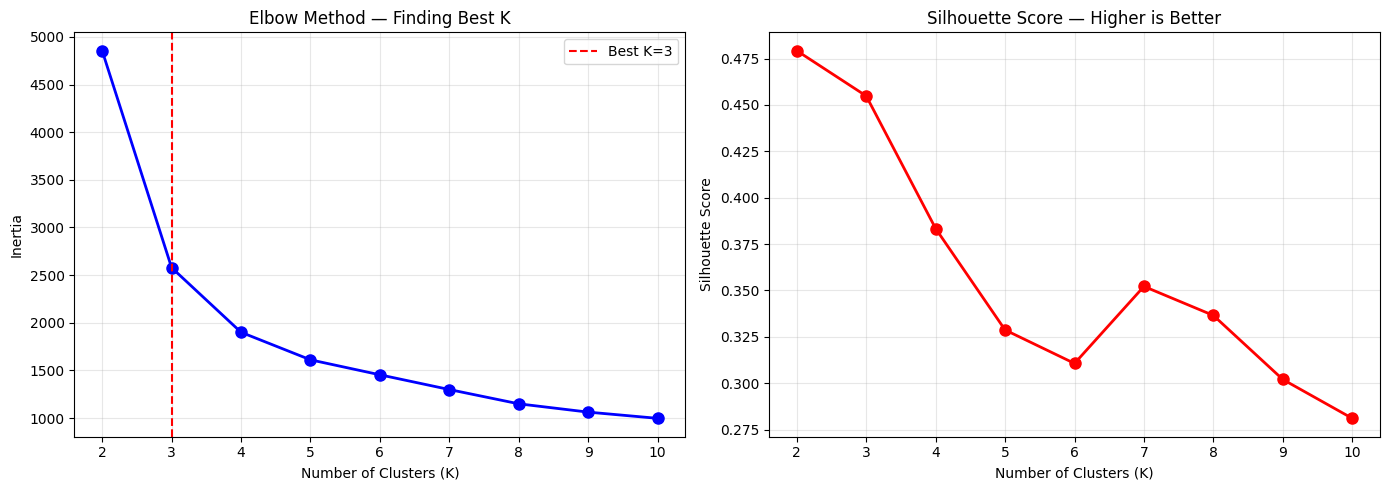

✅ Elbow chart saved!


In [3]:
# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Finding Best K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=3, color='red', linestyle='--', label='Best K=3')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score — Higher is Better')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/chart_kmeans_elbow.png')
plt.show()
print("✅ Elbow chart saved!")

In [4]:
# Build final K-Means model with K=3
# 3 groups = High performers, Average, At-risk
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_cluster)

# Add cluster labels to dataframe
df['cluster'] = kmeans.labels_

print("✅ K-Means clustering done!")
print("\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

✅ K-Means clustering done!

Cluster distribution:
cluster
0    218
1     46
2    131
Name: count, dtype: int64


In [5]:
# Understand each cluster
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print("\nCluster Profiles (Average values per cluster):")
print(cluster_summary)

# Name the clusters based on G3 average
for i in range(3):
    avg_grade = df[df['cluster']==i]['G3'].mean()
    label = "🔴 At-Risk" if avg_grade < -0.2 else \
            "🟡 Average" if avg_grade < 0.3 else "🟢 High Performer"
    print(f"Cluster {i}: Avg Grade={avg_grade:.2f} → {label}")


Cluster Profiles (Average values per cluster):
         studytime  failures  absences    G1    G2     G3
cluster                                                  
0            -0.04      0.03      0.17 -0.40 -0.30   9.68
1            -0.17      0.84     -0.44 -1.11 -1.57   0.85
2             0.13     -0.34     -0.13  1.06  1.05  15.00
Cluster 0: Avg Grade=9.68 → 🟢 High Performer
Cluster 1: Avg Grade=0.85 → 🟢 High Performer
Cluster 2: Avg Grade=15.00 → 🟢 High Performer


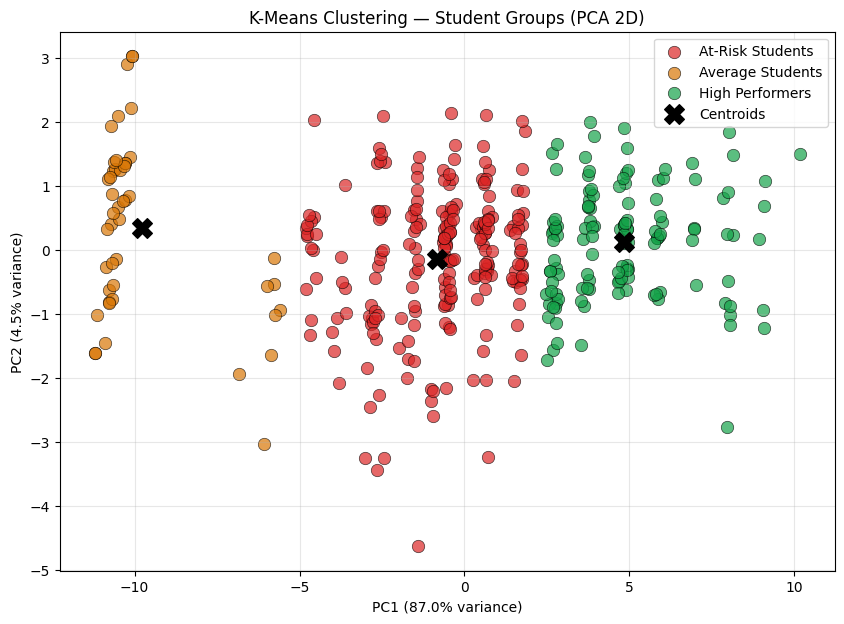

✅ Cluster visualisation saved!


In [6]:
# Use PCA to reduce to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

# Create scatter plot
plt.figure(figsize=(10, 7))
colors  = ['#DC2626', '#D97706', '#16A34A']
labels  = ['At-Risk Students', 'Average Students', 'High Performers']

for i in range(3):
    mask = df['cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=labels[i],
                alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=200,
            label='Centroids', zorder=5)

plt.title('K-Means Clustering — Student Groups (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../notebooks/chart_kmeans_clusters.png')
plt.show()
print("✅ Cluster visualisation saved!")

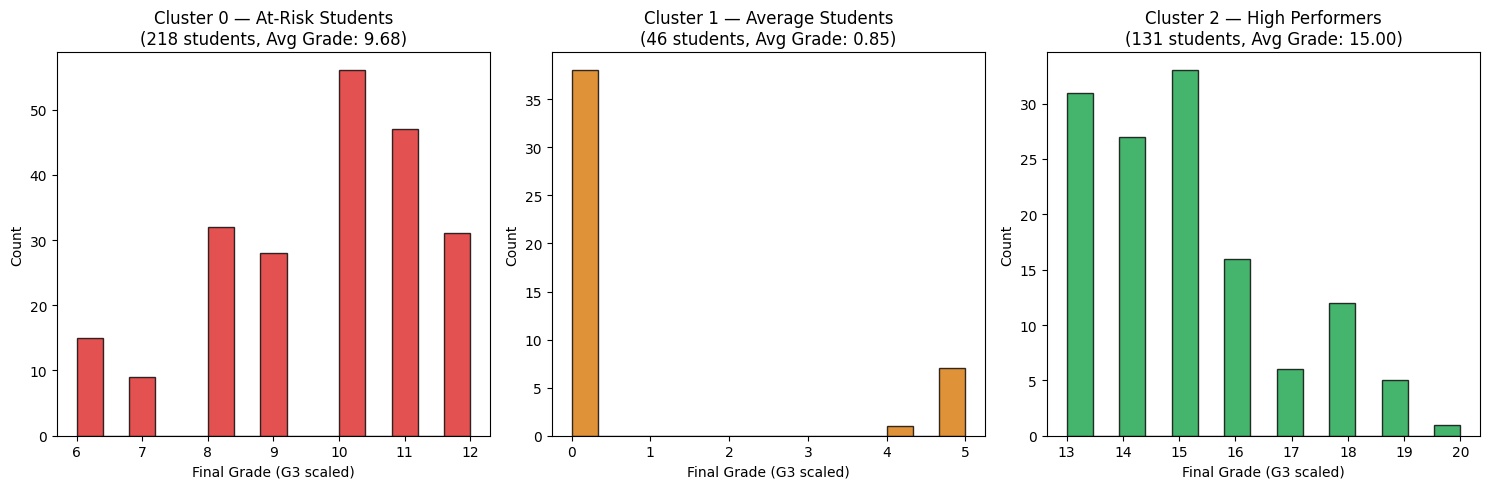

✅ Cluster profiles saved!


In [7]:
# Detailed profile of each cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    cluster_data = df[df['cluster'] == i]
    ax.hist(cluster_data['G3'], bins=15,
            color=colors[i], edgecolor='black', alpha=0.8)
    ax.set_title(f'Cluster {i} — {labels[i]}\n'
                 f'({len(cluster_data)} students, '
                 f'Avg Grade: {cluster_data["G3"].mean():.2f})')
    ax.set_xlabel('Final Grade (G3 scaled)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../notebooks/chart_cluster_profiles.png')
plt.show()
print("✅ Cluster profiles saved!")

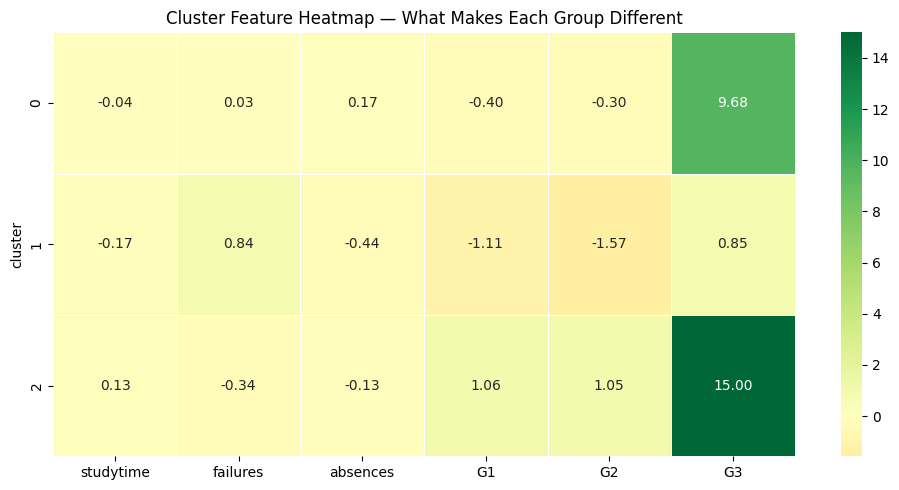

✅ Cluster heatmap saved!


In [8]:
# Heatmap of cluster features
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_summary,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5)
plt.title('Cluster Feature Heatmap — What Makes Each Group Different')
plt.tight_layout()
plt.savefig('../notebooks/chart_cluster_heatmap.png')
plt.show()
print("✅ Cluster heatmap saved!")

In [9]:
# GMM — soft clustering (students can belong to multiple groups!)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_cluster)

gmm_labels = gmm.predict(X_cluster)
gmm_probs  = gmm.predict_proba(X_cluster)

df['gmm_cluster'] = gmm_labels

print("✅ GMM clustering done!")
print("\nGMM Cluster distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())

# Show soft probabilities for first 5 students
print("\nSoft membership probabilities (first 5 students):")
prob_df = pd.DataFrame(gmm_probs.round(3),
                        columns=['Group 0', 'Group 1', 'Group 2'])
print(prob_df.head())

✅ GMM clustering done!

GMM Cluster distribution:
0     67
1     38
2    290
Name: count, dtype: int64

Soft membership probabilities (first 5 students):
   Group 0  Group 1  Group 2
0      0.0      0.0      1.0
1      0.0      0.0      1.0
2      1.0      0.0      0.0
3      0.0      0.0      1.0
4      0.0      0.0      1.0


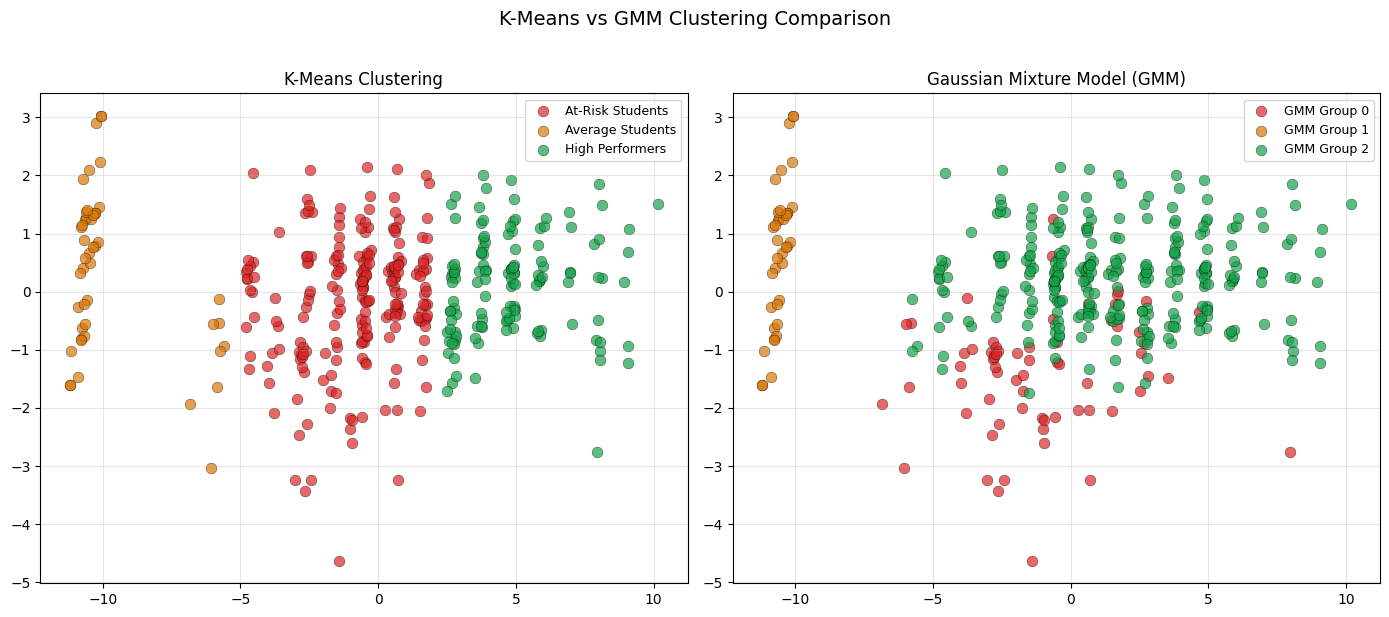

✅ Comparison chart saved!


In [10]:
# Compare K-Means vs GMM
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
for i in range(3):
    mask = df['cluster'] == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=labels[i],
                    alpha=0.7, s=60, edgecolors='black', linewidth=0.3)
axes[0].set_title('K-Means Clustering')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# GMM
for i in range(3):
    mask = df['gmm_cluster'] == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=f'GMM Group {i}',
                    alpha=0.7, s=60, edgecolors='black', linewidth=0.3)
axes[1].set_title('Gaussian Mixture Model (GMM)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('K-Means vs GMM Clustering Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/chart_kmeans_vs_gmm.png')
plt.show()
print("✅ Comparison chart saved!")

In [12]:
# EduTwin specific insight — peer learning groups
import os
print("="*55)
print("   EDUTWIN CLUSTERING INSIGHT")
print("="*55)
print(f"\nTotal students clustered: {len(df)}")
print(f"\nGroup 0 — {labels[0]}: {sum(df['cluster']==0)} students")
print(f"  → These students need IMMEDIATE intervention")
print(f"  → EduTwin will alert their teachers daily")
print(f"\nGroup 1 — {labels[1]}: {sum(df['cluster']==1)} students")
print(f"  → These students need regular check-ins")
print(f"  → EduTwin will send weekly study plans")
print(f"\nGroup 2 — {labels[2]}: {sum(df['cluster']==2)} students")
print(f"  → These students are thriving")
print(f"  → EduTwin will match them as peer tutors")
print("="*55)

# Save models
os.makedirs('../models', exist_ok=True)

with open('../models/kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('../models/gmm.pkl', 'wb') as f:
    pickle.dump(gmm, f)

with open('../models/pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print("\n✅ KMeans model saved!")
print("✅ GMM model saved!")
print("✅ PCA model saved!")

   EDUTWIN CLUSTERING INSIGHT

Total students clustered: 395

Group 0 — At-Risk Students: 218 students
  → These students need IMMEDIATE intervention
  → EduTwin will alert their teachers daily

Group 1 — Average Students: 46 students
  → These students need regular check-ins
  → EduTwin will send weekly study plans

Group 2 — High Performers: 131 students
  → These students are thriving
  → EduTwin will match them as peer tutors

✅ KMeans model saved!
✅ GMM model saved!
✅ PCA model saved!
